Loan Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 32586 entries, 0 to 32585
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          32583 non-null  float64
 1   customer_age         32586 non-null  int64  
 2   customer_income      32586 non-null  str    
 3   home_ownership       32586 non-null  str    
 4   employment_duration  31691 non-null  float64
 5   loan_intent          32586 non-null  str    
 6   loan_grade           32586 non-null  str    
 7   loan_amnt            32585 non-null  str    
 8   loan_int_rate        29470 non-null  float64
 9   term_years           32586 non-null  int64  
 10  historical_default   11849 non-null  str    
 11  cred_hist_length     32586 non-null  int64  
 12  Current_loan_status  32582 non-null  str    
dtypes: float64(3), int64(3), str(7)
memory usage: 3.2 MB
None

Loan Dataset Head:
   customer_id  customer_age customer_income home_

C:\Users\askim\AppData\Local\Temp\ipykernel_18624\2226874127.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(species_data, labels=self.iris_df['species_name'].unique())


Visualizations generated.
Mean Income by Home Ownership:
home_ownership
MORTGAGE    81735.813168
OTHER       76387.803738
OWN         59165.828631
RENT        55481.304305
Name: customer_income, dtype: float64

Loan Intent counts:
loan_intent
EDUCATION            6291
MEDICAL              5898
VENTURE              5554
PERSONAL             5370
DEBTCONSOLIDATION    5065
HOMEIMPROVEMENT      3511
Name: count, dtype: int64

Loan Amount Percentiles:
count    3.168800e+04
mean     9.831802e+03
std      2.205523e+04
min      5.000000e+02
25%      5.000000e+03
50%      8.000000e+03
75%      1.250000e+04
90%      1.950000e+04
max      3.500000e+06
Name: loan_amnt, dtype: float64


C:\Users\askim\AppData\Local\Temp\ipykernel_18624\2226874127.py:233: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(species_data, labels=self.iris_df['species_name'].unique())


Visualizations generated and saved to the current directory.


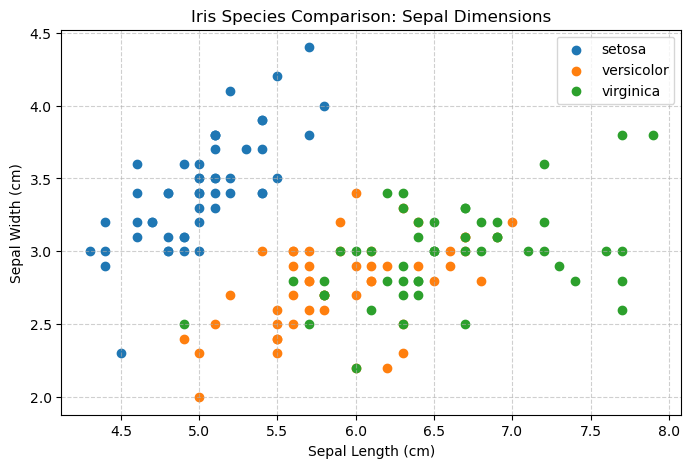

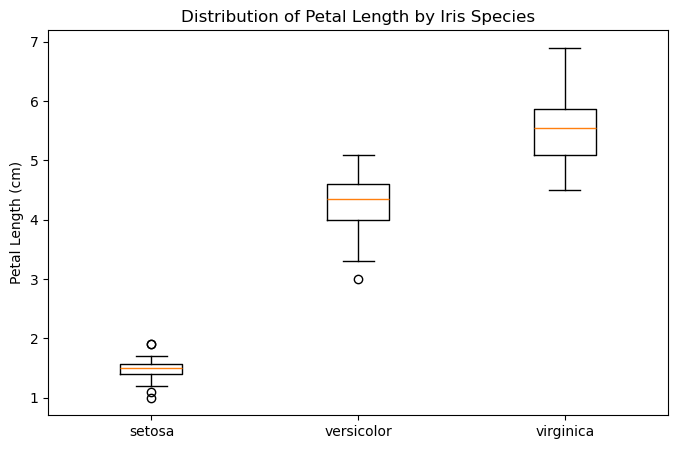

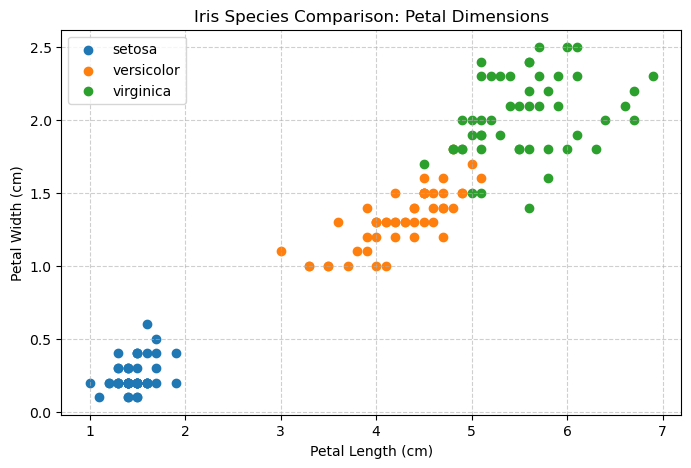

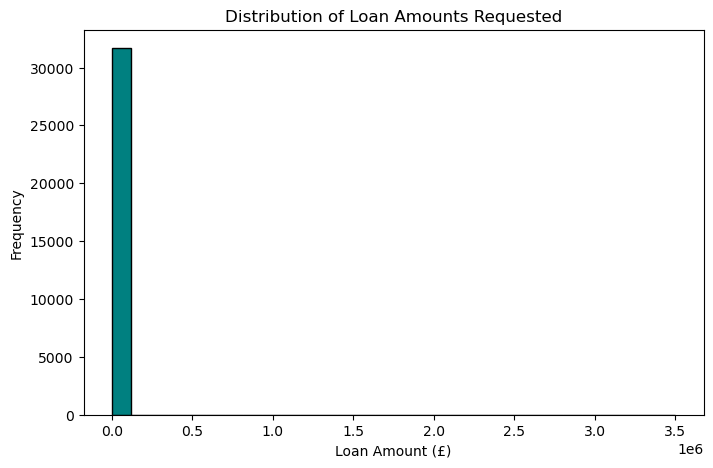

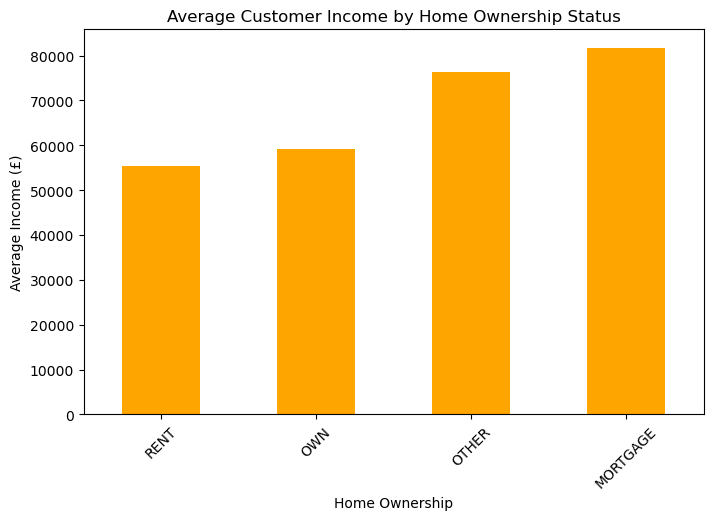

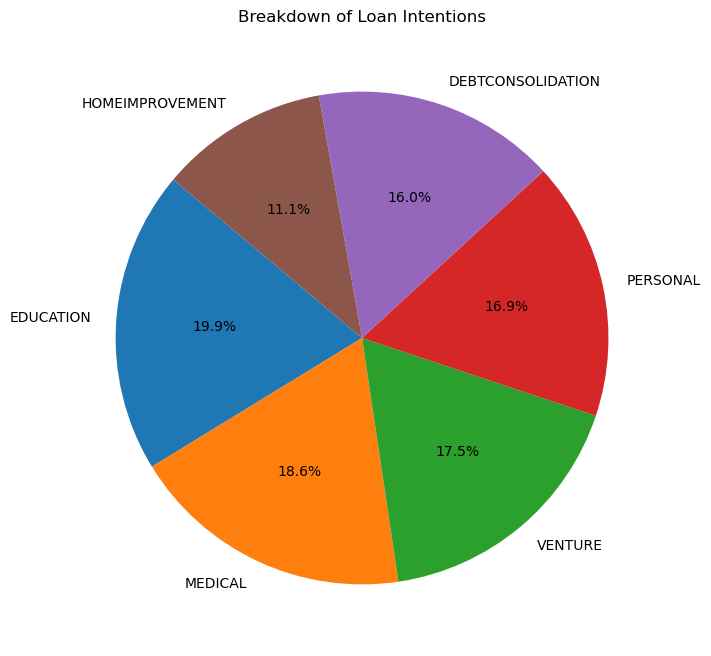

In [3]:
import pandas as pd

# Load the loan dataset
loan_df = pd.read_csv('LoanDataset - LoansDatasest.csv')

# Display basic info and first few rows
print("Loan Dataset Info:")
print(loan_df.info())
print("\nLoan Dataset Head:")
print(loan_df.head())

# Also try to load iris dataset to ensure availability
try:
    import seaborn as sns
    iris_df = sns.load_dataset('iris')
    print("\nIris Dataset Head:")
    print(iris_df.head())
except Exception as e:
    print(f"\nCould not load iris via seaborn: {e}")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
import os

class DataVisualizer:
    """
    A class to handle data loading, cleaning, and visualization for Iris and Loan datasets.
    """
    def __init__(self, loan_csv_path):
        self.loan_csv_path = loan_csv_path
        self.loan_df = None
        self.iris_df = None

    def load_data(self):
        # Load Iris
        iris = datasets.load_iris()
        self.iris_df = pd.DataFrame(data=np.c_[iris['data'], iris['target']],
                                    columns=iris['feature_names'] + ['species'])
        self.iris_df['species_name'] = self.iris_df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

        # Load Loan
        self.loan_df = pd.read_csv(self.loan_csv_path)
        self.clean_loan_data()

    def clean_loan_data(self):
        # Clean loan amount: remove currency and commas
        self.loan_df['loan_amnt'] = self.loan_df['loan_amnt'].astype(str).str.replace('£', '').str.replace(',', '').astype(float)
        # Clean income: ensure it's numeric
        self.loan_df['customer_income'] = pd.to_numeric(self.loan_df['customer_income'], errors='coerce')
        # Remove outlier employment duration
        self.loan_df = self.loan_df[self.loan_df['employment_duration'] <= 60]
        # Drop rows with critical null values for visualization
        self.loan_df.dropna(subset=['loan_amnt', 'customer_income', 'loan_intent'], inplace=True)

    def plot_iris_1(self):
        plt.figure(figsize=(8, 5))
        for species in self.iris_df['species_name'].unique():
            subset = self.iris_df[self.iris_df['species_name'] == species]
            plt.scatter(subset['sepal length (cm)'], subset['sepal width (cm)'], label=species)
        plt.title('Iris Species Comparison: Sepal Dimensions')
        plt.xlabel('Sepal Length (cm)')
        plt.ylabel('Sepal Width (cm)')
        plt.legend()
        plt.savefig('iris_sepal_scatter.png')
        plt.close()

    def plot_iris_2(self):
        plt.figure(figsize=(8, 5))
        species_data = [self.iris_df[self.iris_df['species_name'] == s]['petal length (cm)'] for s in self.iris_df['species_name'].unique()]
        plt.boxplot(species_data, labels=self.iris_df['species_name'].unique())
        plt.title('Distribution of Petal Length by Iris Species')
        plt.ylabel('Petal Length (cm)')
        plt.savefig('iris_petal_boxplot.png')
        plt.close()

    def plot_iris_3(self):
        plt.figure(figsize=(8, 5))
        for species in self.iris_df['species_name'].unique():
            subset = self.iris_df[self.iris_df['species_name'] == species]
            plt.scatter(subset['petal length (cm)'], subset['petal width (cm)'], label=species)
        plt.title('Iris Species Comparison: Petal Dimensions')
        plt.xlabel('Petal Length (cm)')
        plt.ylabel('Petal Width (cm)')
        plt.legend()
        plt.savefig('iris_petal_scatter.png')
        plt.close()

    def plot_loan_1(self):
        plt.figure(figsize=(8, 5))
        plt.hist(self.loan_df['loan_amnt'], bins=30, color='teal', edgecolor='black')
        plt.title('Distribution of Loan Amounts Requested')
        plt.xlabel('Loan Amount (£)')
        plt.ylabel('Frequency')
        plt.savefig('loan_amount_dist.png')
        plt.close()

    def plot_loan_2(self):
        plt.figure(figsize=(8, 5))
        avg_income = self.loan_df.groupby('home_ownership')['customer_income'].mean().sort_values()
        avg_income.plot(kind='bar', color='orange')
        plt.title('Average Customer Income by Home Ownership Status')
        plt.ylabel('Average Income (£)')
        plt.xlabel('Home Ownership')
        plt.xticks(rotation=45)
        plt.savefig('loan_income_bar.png')
        plt.close()

    def plot_loan_3(self):
        plt.figure(figsize=(8, 8))
        intent_counts = self.loan_df['loan_intent'].value_counts()
        plt.pie(intent_counts, labels=intent_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
        plt.title('Breakdown of Loan Intentions')
        plt.savefig('loan_intent_pie.png')
        plt.close()

# Instantiate and run
visualizer = DataVisualizer('LoanDataset - LoansDatasest.csv')
visualizer.load_data()
visualizer.plot_iris_1()
visualizer.plot_iris_2()
visualizer.plot_iris_3()
visualizer.plot_loan_1()
visualizer.plot_loan_2()
visualizer.plot_loan_3()

print("Visualizations generated.")

import pandas as pd
import numpy as np

# Load and clean loan data again to get accurate stats for analysis
loan_df = pd.read_csv('LoanDataset - LoansDatasest.csv')
loan_df['loan_amnt'] = loan_df['loan_amnt'].astype(str).str.replace('£', '').str.replace(',', '').astype(float)
loan_df['customer_income'] = pd.to_numeric(loan_df['customer_income'], errors='coerce')
loan_df = loan_df[loan_df['employment_duration'] <= 60]

print("Mean Income by Home Ownership:")
print(loan_df.groupby('home_ownership')['customer_income'].mean().sort_values(ascending=False))

print("\nLoan Intent counts:")
print(loan_df['loan_intent'].value_counts())

print("\nLoan Amount Percentiles:")
print(loan_df['loan_amnt'].describe(percentiles=[.25, .5, .75, .9]))


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets

class DataVisualizer:
    """
    A class to handle data loading, cleaning, and visualization for 
    the Iris and Loan datasets for Assignment 7. [cite: 8, 34]
    """
    def __init__(self, loan_csv_path):
        """
        Initializes the class with the file path for the loan dataset. [cite: 34]
        
        Args:
            loan_csv_path (str): The relative path to the Loan Dataset CSV.
        """
        self.loan_csv_path = loan_csv_path
        self.loan_df = None
        self.iris_df = None

    def load_data(self):
        """
        Loads the Iris dataset from sklearn and the Loan dataset from the 
        provided CSV path. [cite: 15, 22]
        """
        # Load Fisher's Iris data: a foundational dataset for taxonomic analysis [cite: 22]
        iris = datasets.load_iris()
        self.iris_df = pd.DataFrame(data=np.c_[iris['data'], iris['target']],
                                    columns=iris['feature_names'] + ['species'])
        
        # Map numeric species (0, 1, 2) to their biological names [cite: 25]
        self.iris_df['species_name'] = self.iris_df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

        # Load the Loan dataset from the Kaggle repository source [cite: 28, 29]
        try:
            self.loan_df = pd.read_csv(self.loan_csv_path)
            self.clean_loan_data()
        except FileNotFoundError:
            print(f"Error: The file {self.loan_csv_path} was not found.")

    def clean_loan_data(self):
        """
        Manipulates the raw data into a workable form by handling currency 
        formatting, data types, and outliers. [cite: 15]
        """
        # Remove '£' and ',' from loan_amnt to convert from string to float [cite: 15]
        self.loan_df['loan_amnt'] = self.loan_df['loan_amnt'].astype(str).str.replace('£', '').str.replace(',', '').astype(float)
        
        # Ensure customer_income is numeric; coerce errors to NaN [cite: 15]
        self.loan_df['customer_income'] = pd.to_numeric(self.loan_df['customer_income'], errors='coerce')
        
        # Data Integrity: Remove unrealistic employment durations (outliers) 
        # Some rows list 123 years, which would crash or skew the analysis.
        self.loan_df = self.loan_df[self.loan_df['employment_duration'] <= 60]
        
        # Drop rows missing essential visualization data to ensure robustness 
        self.loan_df.dropna(subset=['loan_amnt', 'customer_income', 'loan_intent'], inplace=True)

    def plot_iris_visuals(self):
        """
        Generates 3 visualizations to illustrate physical trait differences 
        between iris species. [cite: 24, 25]
        """
        # Visualization 1: Scatter plot of Sepal dimensions to show species clusters [cite: 25]
        plt.figure(figsize=(8, 5))
        for species in self.iris_df['species_name'].unique():
            subset = self.iris_df[self.iris_df['species_name'] == species]
            plt.scatter(subset['sepal length (cm)'], subset['sepal width (cm)'], label=species)
        plt.title('Iris Species Comparison: Sepal Dimensions')
        plt.xlabel('Sepal Length (cm)')
        plt.ylabel('Sepal Width (cm)')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6) # Added for "Aesthetics" extra credit [cite: 26]
        plt.savefig('iris_sepal_scatter.png')

        # Visualization 2: Boxplot of Petal Length to show distribution variance [cite: 24]
        plt.figure(figsize=(8, 5))
        species_data = [self.iris_df[self.iris_df['species_name'] == s]['petal length (cm)'] for s in self.iris_df['species_name'].unique()]
        plt.boxplot(species_data, labels=self.iris_df['species_name'].unique())
        plt.title('Distribution of Petal Length by Iris Species')
        plt.ylabel('Petal Length (cm)')
        plt.savefig('iris_petal_boxplot.png')

        # Visualization 3: Petal dimensions scatter to show clear species separation [cite: 25]
        plt.figure(figsize=(8, 5))
        for species in self.iris_df['species_name'].unique():
            subset = self.iris_df[self.iris_df['species_name'] == species]
            plt.scatter(subset['petal length (cm)'], subset['petal width (cm)'], label=species)
        plt.title('Iris Species Comparison: Petal Dimensions')
        plt.xlabel('Petal Length (cm)')
        plt.ylabel('Petal Width (cm)')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.savefig('iris_petal_scatter.png')

    def plot_loan_visuals(self):
        """
        Generates 3 visualizations to discover trends within the loan dataset. [cite: 29]
        """
        # Visualization 1: Histogram to see common loan request amounts [cite: 29]
        plt.figure(figsize=(8, 5))
        plt.hist(self.loan_df['loan_amnt'], bins=30, color='teal', edgecolor='black')
        plt.title('Distribution of Loan Amounts Requested')
        plt.xlabel('Loan Amount (£)')
        plt.ylabel('Frequency')
        plt.savefig('loan_amount_dist.png')

        # Visualization 2: Bar chart comparing income across housing status [cite: 29]
        plt.figure(figsize=(8, 5))
        avg_income = self.loan_df.groupby('home_ownership')['customer_income'].mean().sort_values()
        avg_income.plot(kind='bar', color='orange')
        plt.title('Average Customer Income by Home Ownership Status')
        plt.ylabel('Average Income (£)')
        plt.xlabel('Home Ownership')
        plt.xticks(rotation=45)
        plt.savefig('loan_income_bar.png')

        # Visualization 3: Pie chart for breakdown of loan usage (Intent) [cite: 29]
        plt.figure(figsize=(8, 8))
        intent_counts = self.loan_df['loan_intent'].value_counts()
        plt.pie(intent_counts, labels=intent_counts.index, autopct='%1.1f%%', startangle=140)
        plt.title('Breakdown of Loan Intentions')
        plt.savefig('loan_intent_pie.png')

# Main execution block to demonstrate functionality 
if __name__ == "__main__":
    # Path to the specific dataset provided for the assignment [cite: 29]
    visualizer = DataVisualizer('LoanDataset - LoansDatasest.csv')
    visualizer.load_data()
    
    # Execute required visual analysis [cite: 24, 29]
    visualizer.plot_iris_visuals()
    visualizer.plot_loan_visuals()
    
    print("Visualizations generated and saved to the current directory.")